# BNPL — Merchant Industry Segmentation and Top 10 Rankings

**Objective:** Create five interpretable industry segments, then recommend the **Top 10 merchants per segment** using the *existing overall ranking score* (including predicted 3-month revenue and fraud penalty). This notebook does **not** change the Top 100 overall ranking.

**Method:** Parse messy merchant tags; inspect industries; apply transparent keyword mapping; rank within each segment; audit coverage, risk flags and outputs. Merchants without an interpretable industry remain **Unknown** and unmatched industries remain **Other** (both retained in full outputs but excluded from the five segment Top 10 lists).

## 1. Load overall merchant rankings

In [1]:
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'data' / 'curated').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Cannot locate data/curated. Open this notebook from inside the project repository.')

INPUT = ROOT / 'data' / 'curated' / 'merchant_rankings' / 'merchant_rankings_all.parquet'
OUTPUT = ROOT / 'data' / 'curated' / 'merchant_segments'
OUTPUT.mkdir(parents=True, exist_ok=True)

merchants = pd.read_parquet(INPUT).copy()
required = {'merchant_abn', 'ranking_score', 'tags'}
missing = required - set(merchants.columns)
if missing:
    raise ValueError(f'Missing required columns: {sorted(missing)}')
if merchants['merchant_abn'].duplicated().any():
    raise ValueError('Expected exactly one row per merchant_abn.')
if merchants['ranking_score'].isna().any():
    raise ValueError('Ranking scores contain missing values; rerun merchant_ranking.ipynb.')
print(f'Loaded {len(merchants):,} merchants from {INPUT}')
print('Available columns:', merchants.columns.tolist())

Loaded 4,422 merchants from /Users/amyliu/Desktop/MAST30034_Project_2/data/curated/merchant_rankings/merchant_rankings_all.parquet
Available columns: ['overall_rank', 'merchant_abn', 'total_transaction_value', 'transaction_count', 'unique_customers', 'avg_transaction_value', 'median_transaction_value', 'std_transaction_value', 'max_transaction_value', 'first_transaction', 'last_transaction', 'active_days', 'active_months', 'consumer_flag_rate', 'merchant_flag_rate', 'any_flagged_transaction_count', 'fraud_flag_observed_count', 'observed_span_days', 'observed_span_months', 'transactions_per_active_month', 'value_per_active_month', 'transactions_per_calendar_month', 'value_per_calendar_month', 'transactions_per_customer', 'value_per_customer', 'active_day_share', 'transaction_value_cv', 'fraud_flag_coverage', 'observed_any_fraud_flag_rate', 'monthly_value_std', 'monthly_value_mean', 'monthly_value_cv', 'months_with_transactions', 'recent_month_value', 'previous_month_value', 'recent_mont

## 2. Parse industry, tier and take rate from messy `tags`

The tag strings vary in brackets, case and punctuation. The parser anchors on the **tier immediately before `take rate:`** rather than splitting on commas (which also occur inside industry names). Take rates are extracted for descriptive analysis only; they are **not** added to the established ranking score.

In [2]:
# Example: '([digital goods: books, movies, music], [a], [take rate: 6.99])'
# Capture industry / tier / rate despite mixed [] and () wrappers.
TAG_PATTERN = re.compile(
    r'^\s*[\[\(\s]*?(?P<industry>.*?)\s*[\]\)]*\s*,\s*'
    r'[\[\(\s]*(?P<tier>[abc])[\]\)\s]*\s*,\s*'
    r'[\[\(\s]*take\s*rate\s*:\s*(?P<rate>\d+(?:\.\d+)?)',
    flags=re.IGNORECASE,
)

def parse_tag(value):
    if value is None or (isinstance(value, float) and pd.isna(value)):
        return pd.Series({'industry': pd.NA, 'merchant_tier': pd.NA, 'take_rate': np.nan})
    text = str(value).strip()
    if not text or text.lower() in ('none', 'nan', '<na>'):
        return pd.Series({'industry': pd.NA, 'merchant_tier': pd.NA, 'take_rate': np.nan})
    match = TAG_PATTERN.search(text)
    if not match:
        return pd.Series({'industry': pd.NA, 'merchant_tier': pd.NA, 'take_rate': np.nan})
    industry = re.sub(r'\s+', ' ', match.group('industry').strip(' []()').lower())
    return pd.Series({
        'industry': industry if industry else pd.NA,
        'merchant_tier': match.group('tier').lower(),
        'take_rate': float(match.group('rate')),
    })

parsed = merchants['tags'].apply(parse_tag)
merchants = pd.concat([merchants, parsed], axis=1)
merchants['tag_parse_failed'] = merchants['tags'].notna() & merchants['industry'].isna()
print('Missing/uncategorisable industries:', merchants['industry'].isna().sum())
print('Non-null tags that failed parsing:', merchants['tag_parse_failed'].sum())
print('Distinct cleaned industries:', merchants['industry'].nunique())
display(merchants[['tags', 'industry', 'merchant_tier', 'take_rate']].head(12))
display(merchants['industry'].value_counts(dropna=False).head(40).rename_axis('industry').reset_index(name='merchants'))

Missing/uncategorisable industries: 547
Non-null tags that failed parsing: 151
Distinct cleaned industries: 25


,tags,industry,merchant_tier,take_rate
0,"((tent and awning shops), (c), (take rate: 2.86))",tent and awning shops,c,2.86
1,"[(florists supplies, nursery stock, and floWer...","florists supplies, nursery stock, and flowers",c,2.94
2,"((opticians, optical goods, and eyeglasses), (...","opticians, optical goods, and eyeglasses",c,2.93
3,"([gift, card, Novelty, and souvenir shops], [b...","gift, card, novelty, and souvenir shops",b,4.69
4,None,<NA>,<NA>,NaN
5,"((music shops - musical instruments, pianos, a...","music shops - musical instruments, pianos, and...",a,6.31
6,"[(gift, card, novelty, and souvenir shops), (c...","gift, card, novelty, and souvenir shops",c,1.47
7,"([gift, card, novelty, and souvenIr shops], [b...","gift, card, novelty, and souvenir shops",b,4.95
8,"((teNt and awning shops), (a), (take rate: 5.80))",tent and awning shops,a,5.80
9,"[[watch, clock, and jewelry repair shops], [a]...","watch, clock, and jewelry repair shops",a,6.43


,industry,merchants
0,<NA>,547
1,"digital goods: books, movies, music",187
2,artist supply and craft shops,186
3,shoe shops,181
4,"computer programming , data processing, and in...",179
5,"furniture, home furnishings and equipment shop...",179
6,"gift, card, novelty, and souvenir shops",178
7,"computers, computer peripheral equipment, and ...",176
8,"florists supplies, nursery stock, and flowers",172
9,tent and awning shops,171


## 3. Define five business-oriented segments

These are **analyst-defined groupings**, not categories supplied by the dataset. Review the unmatched industry table below and expand keywords if necessary. **Other** and **Unknown** are preserved, not silently dropped.

In [3]:
# Ordered keyword rules: first match wins. Keep them interpretable and easy to adjust.
SEGMENT_KEYWORDS = {
    'Fashion & Lifestyle': [
        'shoe', 'clothing', 'apparel', 'fashion', 'jewel', 'watch', 'gift', 'novelty',
        'souvenir', 'florist', 'flower', 'beauty', 'cosmetic', 'accessor', 'leather',
        'luggage', 'department store', 'sporting goods', 'toy', 'game shop',
    ],
    'Electronics & Digital': [
        'digital goods', 'computer', 'software', 'telecom', 'telephone', 'electronic',
        'cable', 'satellite', 'television', 'radio services', 'camera', 'photographic',
        'internet', 'data processing', 'programming', 'appliance',
    ],
    'Home & Living': [
        'furniture', 'home furnishing', 'household', 'hardware', 'building material',
        'garden', 'nursery stock', 'floor covering', 'carpet', 'interior', 'lighting',
        'kitchen', 'home improvement', 'paint', 'decor',
    ],
    'Automotive & Outdoor': [
        'motor vehicle', 'automotive', 'automobile', 'auto part', 'bicycle', 'tent',
        'awning', 'camping', 'marine', 'boat', 'motorcycle', 'tyre', 'tire',
        'recreational vehicle', 'outdoor',
    ],
    'Arts, Media & Services': [
        'art dealer', 'art galler', 'book', 'periodical', 'newspaper', 'music',
        'instrument', 'sheet music', 'entertainment', 'cinema', 'theatre', 'theater',
        'professional service', 'repair', 'education', 'travel', 'hotel',
        'restaurant', 'cafe', 'food', 'health', 'medical', 'optician', 'optical',
    ],
}

SEGMENTS = list(SEGMENT_KEYWORDS)

def assign_segment(industry):
    if pd.isna(industry):
        return 'Unknown'
    for segment, keywords in SEGMENT_KEYWORDS.items():
        if any(keyword in industry for keyword in keywords):
            return segment
    return 'Other'

merchants['segment'] = merchants['industry'].apply(assign_segment)

segment_counts = merchants['segment'].value_counts().rename_axis('segment').reset_index(name='merchant_count')
segment_counts['share_pct'] = (100 * segment_counts['merchant_count'] / len(merchants)).round(1)
display(segment_counts)

print('Unmapped industries (inspect and add keywords if important):')
display(merchants.loc[merchants['segment'].eq('Other'), 'industry']
        .value_counts().rename_axis('industry').reset_index(name='merchant_count').head(60))

print('Top industries in each of the five segments:')
for segment in SEGMENTS:
    print(f'\n{segment}')
    display(merchants.loc[merchants['segment'].eq(segment), 'industry'].value_counts().head(12))

assert merchants['segment'].notna().all()
if any((merchants['segment'] == segment).sum() < 10 for segment in SEGMENTS):
    print('WARNING: At least one segment has fewer than 10 merchants. Review mapping before finalising.')

,segment,merchant_count,share_pct
0,Electronics & Digital,1135,25.7
1,Fashion & Lifestyle,1083,24.5
2,"Arts, Media & Services",696,15.7
3,Unknown,547,12.4
4,Automotive & Outdoor,478,10.8
5,Other,332,7.5
6,Home & Living,151,3.4


Unmapped industries (inspect and add keywords if important):


,industry,merchant_count
0,artist supply and craft shops,186
1,"stationery, office supplies and printing and w...",146


Top industries in each of the five segments:

Fashion & Lifestyle


industry
shoe shops                                       181
gift, card, novelty, and souvenir shops          178
florists supplies, nursery stock, and flowers    172
watch, clock, and jewelry repair shops           167
health and beauty spas                           160
hobby, toy and game shops                        138
jewelry, watch, clock, and silverware shops       87
Name: count, dtype: int64

...

industry
lawn and garden supply outlets, including nurseries    151
Name: count, dtype: int64


Automotive & Outdoor


industry
tent and awning shops                   171
bicycle shops - sales and service       164
motor vehicle supplies and new parts    143
Name: count, dtype: int64


Arts, Media & Services


industry
music shops - musical instruments, pianos, and sheet music    162
books, periodicals, and newspapers                            158
opticians, optical goods, and eyeglasses                      145
antique shops - sales, repairs, and restoration services      121
art dealers and galleries                                     110
Name: count, dtype: int64

## 4. Rank merchants within each segment

**No new scoring weights:** Within each segment, sort by the existing `ranking_score`, which already includes predicted 3-month revenue and the fraud penalty. Ties use overall rank (if available), then merchant ABN. Keep flagged merchants in the results, clearly marked for review.

In [4]:
if 'overall_rank' not in merchants.columns:
    merchants['overall_rank'] = merchants['ranking_score'].rank(method='first', ascending=False).astype(int)

sort_cols = ['segment', 'ranking_score', 'overall_rank', 'merchant_abn']
all_segment_rankings = merchants.sort_values(
    sort_cols, ascending=[True, False, True, True], kind='stable'
).copy()
all_segment_rankings['segment_rank'] = all_segment_rankings.groupby('segment').cumcount() + 1

top_10_per_segment = all_segment_rankings.loc[
    all_segment_rankings['segment'].isin(SEGMENTS) & (all_segment_rankings['segment_rank'] <= 10)
].copy()

show = ['segment', 'segment_rank', 'overall_rank', 'merchant_abn']
show += [c for c in ['name_merchant', 'industry', 'merchant_tier', 'ranking_score',
                     'predicted_3m_revenue', 'total_transaction_value',
                     'unique_customers', 'repeat_customer_share', 'take_rate',
                     'fraud_risk_flag', 'fraud_data_review_flag', 'manual_review_flag']
         if c in top_10_per_segment.columns]

for segment in SEGMENTS:
    print(f'\n### {segment} — Top 10')
    display(top_10_per_segment.loc[top_10_per_segment['segment'].eq(segment), show].reset_index(drop=True))

print('Selected merchants:', len(top_10_per_segment))


### Fashion & Lifestyle — Top 10


,segment,segment_rank,overall_rank,merchant_abn,name_merchant,industry,merchant_tier,ranking_score,predicted_3m_revenue,total_transaction_value,unique_customers,repeat_customer_share,take_rate,fraud_risk_flag,fraud_data_review_flag,manual_review_flag
0,Fashion & Lifestyle,1,2,24852446429,Erat Vitae LLP,"florists supplies, nursery stock, and flowers",c,99.711464,1.368171e+06,8.698780e+06,24080,0.999834,2.94,False,False,False
1,Fashion & Lifestyle,2,4,60956456424,Ultricies Dignissim LLP,"gift, card, novelty, and souvenir shops",b,99.648206,1.591941e+06,8.026971e+06,23499,0.911273,4.69,False,False,False
2,Fashion & Lifestyle,3,7,80324045558,Ipsum Dolor Sit Corporation,"gift, card, novelty, and souvenir shops",c,99.590716,1.407703e+06,7.219970e+06,24076,0.997342,1.47,False,False,False
3,Fashion & Lifestyle,4,8,79417999332,Phasellus At Company,"gift, card, novelty, and souvenir shops",b,99.557306,1.340300e+06,9.126403e+06,23731,0.932493,4.95,False,False,False
4,Fashion & Lifestyle,5,10,86578477987,Leo In Consulting,"watch, clock, and jewelry repair shops",a,99.51913,1.102467e+06,9.539823e+06,24081,0.999917,6.43,False,False,False
5,Fashion & Lifestyle,6,14,43186523025,Lorem Ipsum Sodales Industries,"florists supplies, nursery stock, and flowers",b,99.453918,1.135282e+06,9.041988e+06,24076,0.998006,4.47,False,False,False
6,Fashion & Lifestyle,7,16,45629217853,Lacus Consulting,"gift, card, novelty, and souvenir shops",a,99.388996,1.099183e+06,8.395062e+06,24081,0.999045,6.98,False,False,False
7,Fashion & Lifestyle,8,17,94493496784,Dictum Phasellus In Institute,"gift, card, novelty, and souvenir shops",a,99.372652,1.137992e+06,9.115636e+06,23660,0.935207,5.65,False,False,False
8,Fashion & Lifestyle,9,20,32361057556,Orci In Consequat Corporation,"gift, card, novelty, and souvenir shops",a,99.29955,1.098652e+06,9.434453e+06,23396,0.899555,6.61,False,False,False
9,Fashion & Lifestyle,10,23,49212265466,Auctor Company,"florists supplies, nursery stock, and flowers",b,99.236159,1.520741e+06,8.140125e+06,18683,0.568431,4.50,False,False,False



### Electronics & Digital — Top 10


,segment,segment_rank,overall_rank,merchant_abn,name_merchant,industry,merchant_tier,ranking_score,predicted_3m_revenue,total_transaction_value,unique_customers,repeat_customer_share,take_rate,fraud_risk_flag,fraud_data_review_flag,manual_review_flag
0,Electronics & Digital,1,12,49505931725,Suspendisse Ac Associates,"digital goods: books, movies, music",b,99.483585,1.449208e+06,7.180616e+06,22686,0.825928,4.70,False,False,False
1,Electronics & Digital,2,13,72472909171,Nullam Consulting,"digital goods: books, movies, music",a,99.461434,1.357082e+06,7.139098e+06,23747,0.937466,6.33,False,False,False
2,Electronics & Digital,3,15,68216911708,Placerat Eget Venenatis Limited,"computers, computer peripheral equipment, and ...",c,99.402957,1.256492e+06,6.965564e+06,24065,0.996260,3.05,False,False,False
3,Electronics & Digital,4,18,21439773999,Mauris Non Institute,"cable, satellite, and other pay television and...",a,99.369723,1.095181e+06,9.426657e+06,23914,0.967341,6.10,False,False,False
4,Electronics & Digital,5,21,52959528548,Libero Et Limited,"furniture, home furnishings and equipment shop...",c,99.272333,1.469696e+06,7.251988e+06,19984,0.634357,1.94,False,False,False
5,Electronics & Digital,6,25,38090089066,Interdum Feugiat Sed Inc.,"furniture, home furnishings and equipment shop...",b,99.1965,1.160213e+06,8.891004e+06,21286,0.714930,3.24,False,False,False
6,Electronics & Digital,7,28,90543168331,Phasellus Dapibus Incorporated,"furniture, home furnishings and equipment shop...",c,99.161142,1.433416e+06,9.016103e+06,18519,0.555376,2.68,False,False,False
7,Electronics & Digital,8,31,76767266140,Phasellus At Limited,"furniture, home furnishings and equipment shop...",b,99.020238,1.088626e+06,9.349434e+06,20160,0.645040,4.65,False,False,False
8,Electronics & Digital,9,33,35909341340,Arcu Sed Eu Incorporated,"computer programming , data processing, and in...",b,98.975248,1.099509e+06,9.528214e+06,19131,0.585803,4.80,False,False,False
9,Electronics & Digital,10,37,67400260923,Eleifend PC,"computer programming , data processing, and in...",a,98.796133,1.142867e+06,5.629515e+06,19033,0.581884,5.97,False,False,False



### Home & Living — Top 10


...


### Automotive & Outdoor — Top 10


,segment,segment_rank,overall_rank,merchant_abn,name_merchant,industry,merchant_tier,ranking_score,predicted_3m_revenue,total_transaction_value,unique_customers,repeat_customer_share,take_rate,fraud_risk_flag,fraud_data_review_flag,manual_review_flag
0,Automotive & Outdoor,1,1,64203420245,Pede Nonummy Corp.,tent and awning shops,c,99.789497,1.529798e+06,7.549445e+06,24081,0.999834,2.86,False,False,False
1,Automotive & Outdoor,2,9,49891706470,Non Vestibulum Industries,tent and awning shops,a,99.539119,1.320076e+06,7.171594e+06,24078,0.999751,5.80,False,False,False
2,Automotive & Outdoor,3,11,89726005175,Est Nunc Consulting,tent and awning shops,a,99.494867,1.149440e+06,8.908823e+06,24079,0.998796,6.01,False,False,False
3,Automotive & Outdoor,4,35,96680767841,Ornare Limited,motor vehicle supplies and new parts,a,98.896957,1.175037e+06,9.806731e+06,17471,0.508843,5.91,False,False,False
4,Automotive & Outdoor,5,50,22033359776,Suspendisse Non Leo PC,motor vehicle supplies and new parts,b,98.508899,1.300672e+06,8.867384e+06,15062,0.405989,3.10,False,False,False
5,Automotive & Outdoor,6,62,21359184622,Sit Amet PC,motor vehicle supplies and new parts,b,98.231651,1.411409e+06,6.501298e+06,13872,0.368584,3.60,False,False,False
6,Automotive & Outdoor,7,72,76819856970,Egestas Blandit Ltd,tent and awning shops,b,97.790578,1.405329e+06,7.526629e+06,11948,0.301389,3.19,False,False,False
7,Automotive & Outdoor,8,77,13514558491,Magna Praesent PC,motor vehicle supplies and new parts,a,97.645022,1.138570e+06,5.630545e+06,12667,0.325255,6.78,False,False,False
8,Automotive & Outdoor,9,86,79633007926,Auctor Vitae Inc.,bicycle shops - sales and service,b,97.055546,4.718045e+05,2.268774e+06,12917,0.330727,4.19,False,False,False
9,Automotive & Outdoor,10,87,22227727512,Malesuada Integer Id Foundation,motor vehicle supplies and new parts,b,97.040207,7.424157e+05,4.021015e+06,11686,0.295824,5.03,False,False,False



### Arts, Media & Services — Top 10


,segment,segment_rank,overall_rank,merchant_abn,name_merchant,industry,merchant_tier,ranking_score,predicted_3m_revenue,total_transaction_value,unique_customers,repeat_customer_share,take_rate,fraud_risk_flag,fraud_data_review_flag,manual_review_flag
0,"Arts, Media & Services",1,3,46804135891,Suspendisse Dui Corporation,"opticians, optical goods, and eyeglasses",c,99.688578,1.500878e+06,7.042650e+06,24079,0.999502,2.93,False,False,False
1,"Arts, Media & Services",2,6,64403598239,Lobortis Ultrices Company,"music shops - musical instruments, pianos, and...",a,99.595996,1.367705e+06,8.873434e+06,23875,0.957152,6.31,False,False,False
2,"Arts, Media & Services",3,22,35223308778,Euismod In Corp.,"books, periodicals, and newspapers",b,99.25453,1.401244e+06,7.298182e+06,20417,0.655532,4.19,False,False,False
3,"Arts, Media & Services",4,24,48534649627,Dignissim Maecenas Foundation,"opticians, optical goods, and eyeglasses",a,99.213637,1.090804e+06,9.408958e+06,22580,0.814438,6.64,False,False,False
4,"Arts, Media & Services",5,29,68559320474,Aliquam Auctor Associates,"antique shops - sales, repairs, and restoratio...",b,99.159453,1.505650e+06,7.672531e+06,18537,0.567406,4.20,False,False,False
5,"Arts, Media & Services",6,44,34179569263,Sodales At LLC,"music shops - musical instruments, pianos, and...",b,98.637447,1.599442e+06,7.824988e+06,14802,0.408729,4.72,False,False,False
6,"Arts, Media & Services",7,57,76626119831,Tristique Pellentesque Inc.,"antique shops - sales, repairs, and restoratio...",c,98.361769,6.561477e+05,3.840745e+06,18680,0.563972,1.99,False,False,False
7,"Arts, Media & Services",8,59,46298404088,Feugiat Sed Nec Institute,"books, periodicals, and newspapers",a,98.334107,5.664795e+05,2.697559e+06,19804,0.626894,6.16,False,False,False
8,"Arts, Media & Services",9,75,99291944648,Rutrum Magna Cras LLC,"books, periodicals, and newspapers",b,97.736223,1.593566e+06,7.549516e+06,11375,0.289582,3.73,False,False,False
9,"Arts, Media & Services",10,76,11237511112,Magna Institute,"opticians, optical goods, and eyeglasses",c,97.725002,9.343029e+05,4.464216e+06,13923,0.365726,2.11,False,False,False


Selected merchants: 50


## 5. Segment comparison and risk review

Interpret figures as descriptive only. Review flagged merchants before making onboarding recommendations; the score does not automatically approve a merchant.

,segment,merchant_count,median_ranking_score,mean_ranking_score,median_predicted_3m_revenue,median_historical_transaction_value,median_unique_customers,median_take_rate,fraud_risk_flag_share,fraud_data_review_flag_share,manual_review_flag_share
2,Electronics & Digital,1135,54.775613,56.844755,28657.755357,139659.035713,453.0,4.74,0.0,0.0,0.111894
3,Fashion & Lifestyle,1083,53.721524,56.646774,28166.171890,126895.456879,500.0,4.65,0.0,0.0,0.084026
0,"Arts, Media & Services",696,47.372608,51.999849,32460.773457,137273.798432,208.5,4.40,0.00431,0.0,0.176724
6,Unknown,547,45.236679,50.117631,37313.969827,134017.968666,123.0,NaN,0.009141,0.0,0.265082
1,Automotive & Outdoor,478,57.275535,56.883398,31978.587553,163040.160792,510.5,4.65,0.0,0.0,0.106695
5,Other,332,53.2962,53.831398,29006.208825,149626.998613,290.5,4.31,0.0,0.0,0.051205
4,Home & Living,151,56.883332,57.537803,32872.902755,182056.285224,404.0,4.96,0.0,0.0,0.092715


Top 10 merchants flagged for manual review by segment:


segment
Arts, Media & Services    0
Automotive & Outdoor      0
Electronics & Digital     0
Fashion & Lifestyle       0
Home & Living             0
Name: flagged_merchants, dtype: Int64

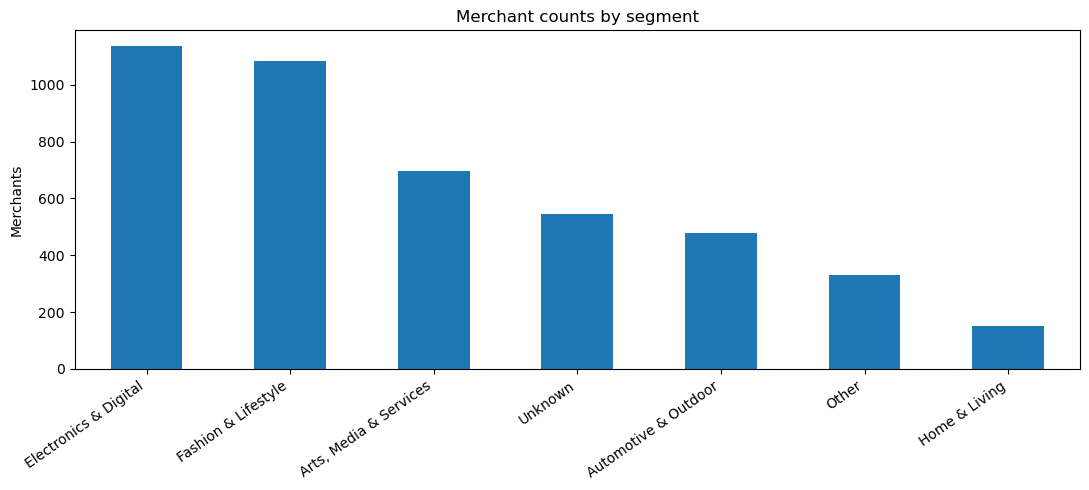

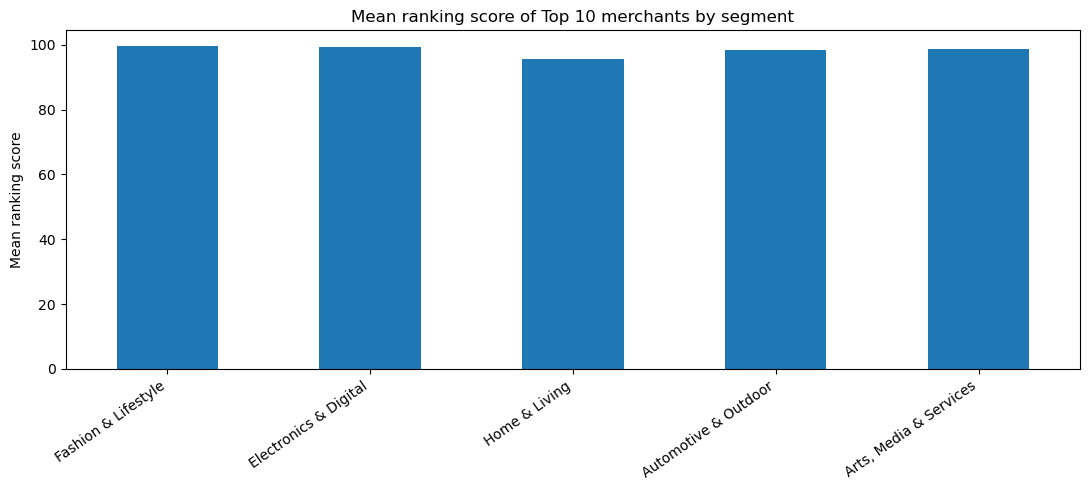

In [5]:
summary = merchants.groupby('segment', dropna=False).agg(
    merchant_count=('merchant_abn', 'size'),
    median_ranking_score=('ranking_score', 'median'),
    mean_ranking_score=('ranking_score', 'mean'),
)
for col, label in [
    ('predicted_3m_revenue', 'median_predicted_3m_revenue'),
    ('total_transaction_value', 'median_historical_transaction_value'),
    ('unique_customers', 'median_unique_customers'),
    ('take_rate', 'median_take_rate'),
]:
    if col in merchants.columns:
        summary[label] = merchants.groupby('segment')[col].median()
for col in ['fraud_risk_flag', 'fraud_data_review_flag', 'manual_review_flag']:
    if col in merchants.columns:
        summary[col + '_share'] = merchants.groupby('segment')[col].mean()
summary = summary.reset_index().sort_values('merchant_count', ascending=False)
display(summary)

if 'manual_review_flag' in top_10_per_segment.columns:
    print('Top 10 merchants flagged for manual review by segment:')
    display(top_10_per_segment.groupby('segment')['manual_review_flag'].sum().rename('flagged_merchants'))

fig, ax = plt.subplots(figsize=(11, 5))
segment_counts.plot.bar(x='segment', y='merchant_count', ax=ax, legend=False)
ax.set(title='Merchant counts by segment', xlabel='', ylabel='Merchants')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(11, 5))
plot_df = top_10_per_segment.groupby('segment')['ranking_score'].mean().reindex(SEGMENTS)
plot_df.plot.bar(ax=ax)
ax.set(title='Mean ranking score of Top 10 merchants by segment', xlabel='', ylabel='Mean ranking score')
plt.xticks(rotation=35, ha='right')
plt.tight_layout()
plt.show()

## 6. Validate and export

Outputs are saved separately from the overall Top 100 ranking. The five selected segments should produce 50 rows if each has at least ten merchants.

In [6]:
assert len(all_segment_rankings) == len(merchants)
assert all_segment_rankings['merchant_abn'].is_unique
assert top_10_per_segment.groupby('segment').size().le(10).all()
assert top_10_per_segment['segment_rank'].between(1, 10).all()
assert set(top_10_per_segment['segment']).issubset(SEGMENTS)
assert all_segment_rankings.groupby('segment')['segment_rank'].min().eq(1).all()

all_segment_rankings.to_parquet(OUTPUT / 'merchant_segment_rankings_all.parquet', index=False)
all_segment_rankings.to_csv(OUTPUT / 'merchant_segment_rankings_all.csv', index=False)
top_10_per_segment.to_parquet(OUTPUT / 'top_10_per_segment.parquet', index=False)
top_10_per_segment.to_csv(OUTPUT / 'top_10_per_segment.csv', index=False)
segment_counts.to_csv(OUTPUT / 'segment_counts.csv', index=False)
summary.to_csv(OUTPUT / 'segment_summary.csv', index=False)

print('Saved outputs to:', OUTPUT)
for path in sorted(OUTPUT.glob('*')):
    print(' -', path.name)
print('Top 10 counts:', top_10_per_segment.groupby('segment').size().to_dict())

Saved outputs to: /Users/amyliu/Desktop/MAST30034_Project_2/data/curated/merchant_segments
 - merchant_segment_rankings_all.csv
 - merchant_segment_rankings_all.parquet
 - segment_counts.csv
 - segment_summary.csv
 - top_10_per_segment.csv
 - top_10_per_segment.parquet
Top 10 counts: {'Arts, Media & Services': 10, 'Automotive & Outdoor': 10, 'Electronics & Digital': 10, 'Fashion & Lifestyle': 10, 'Home & Living': 10}


## 7. Notes for the final report / presentation

- **Segmentation rationale:** Five industry-based segments provide interpretable comparisons and help assess portfolio diversification.
- **Ranking method:** Within each segment, retain the same overall weighted merchant score (including predicted 3-month revenue and fraud penalty) to ensure consistency with the overall Top 100.
- **Data limitations:** Merchant tags are messy and missing for some merchants. Unmapped labels are retained as `Other`, missing/unparseable tags as `Unknown`; audit these before finalising.
- **Risk:** Fraud and data-quality flags remain visible; a high score is not automatic approval.
- **Commercial interpretation:** `take_rate` is extracted but **not used in scoring**. If its units and relationship to BNPL fee revenue are confirmed, a separate take-rate-adjusted sensitivity analysis could be justified.
- **Next:** Review the top industries within each segment and adjust the keyword mapping if the current five groups are unbalanced or poorly matched.